# AI-Based Loan Approval Prediction

## Objective:
To predict whether a loan should be approved or rejected using machine learning.

## Business Value:
- Faster loan decisions
- Reduced risk of default
- Better financial inclusion

**Step 1:**
We are importing tools to work with data.

In [1]:
import pandas as pd
import numpy as np


**Step 2: Connecting Google Drive**


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 3:** Loading Dataset from Google Drive

We have stored our dataset in Google Drive.  
We will use the file path to directly load the training and testing data into our notebook.

In [9]:
train = pd.read_csv("/content/drive/MyDrive/Loan_Prediction_Project/dataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Loan_Prediction_Project/dataset/test.csv")

train.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Step 4:**
**Dataset Info**

Number of rows

Data types (text, numbers)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**Step 5:** Dataset Description

In [11]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**Step 6:** Drop Irrelevant Column

Loan_ID is not useful for prediction.

In [12]:
train.drop('Loan_ID', axis=1, inplace=True)
test.drop('Loan_ID', axis=1, inplace=True)

**Step 7: Checking Missing Values**

It will show missing values column-wise.

In [13]:
train.isnull().sum()


,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


**Step 8: We will Handle All Missing Values:**

1. Categorical Columns → Mode

In [14]:
for col in ['Gender','Married','Dependents','Self_Employed']:
    train[col].fillna(train[col].mode()[0], inplace=True)

/tmp/ipykernel_6307/3467590293.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)


2. Numerical Columns → Mean

In [15]:
train['LoanAmount'].fillna(train['LoanAmount'].mean(), inplace=True)
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mean(), inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mean(), inplace=True)

/tmp/ipykernel_6307/3965774323.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['LoanAmount'].fillna(train['LoanAmount'].mean(), inplace=True)
/tmp/ipykernel_6307/3965774323.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Verify (IMPORTANT)

In [16]:
train.isnull().sum()


,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


**Step 9: Convert Text → Numbers (Encoding)**

We will convert categorical data into numerical form so machine learning models can process it.

In [31]:
from sklearn.preprocessing import LabelEncoder

for col in train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])

In [32]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [34]:
# Handle Missing Values (Test)
for col in ['Gender','Married','Dependents','Self_Employed']:
    test[col].fillna(test[col].mode()[0], inplace=True)

test['LoanAmount'].fillna(test['LoanAmount'].mean(), inplace=True)
test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mean(), inplace=True)
test['Credit_History'].fillna(test['Credit_History'].mean(), inplace=True)

/tmp/ipykernel_6307/1103212005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].mode()[0], inplace=True)
/tmp/ipykernel_6307/1103212005.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [35]:
# Encode test data
from sklearn.preprocessing import LabelEncoder

for col in test.select_dtypes(include='object').columns:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])


In [37]:
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1.000000,2
1,1,1,1,0,0,3076,1500,126.0,360.0,1.000000,2
2,1,1,2,0,0,5000,1800,208.0,360.0,1.000000,2
3,1,1,2,0,0,2340,2546,100.0,360.0,0.825444,2
4,1,0,0,1,0,3276,0,78.0,360.0,1.000000,2


In [36]:
# verify
test.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


**Step 10: Training Logistic Regression Model**

🔹 1. Define Features & Target

X is input data, y is what we want to predict.

In [38]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

🔹 2. Train Logistic Regression (Simple Model for Binary Classification)

We are training the model using "train" data.

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

🔹 3. Predict on Test Data

The model learns patterns from past data and predicts loan approval for new applicants

In [40]:
predictions = model.predict(test)

In [41]:
predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

**Step 11: Training Random Forest Model (Better Model)**

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

**Predictions using Random Forest**

In [44]:
rf_pred = rf.predict(test)

In [45]:
rf_pred[:10]

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1])

**Step 12: Visual Comparison**

We compare actual vs predicted results.

In [48]:
comparison = pd.DataFrame({
    "Actual": y,
    "Logistic_Prediction": model.predict(X),
    "RF_Prediction": rf.predict(X)
})

comparison.head(10)


,Actual,Logistic_Prediction,RF_Prediction
0,1,1,1
1,0,1,0
2,1,1,1
3,1,1,1
4,1,1,1
5,1,1,1
6,1,1,1
7,0,0,0
8,1,1,1
9,0,1,0


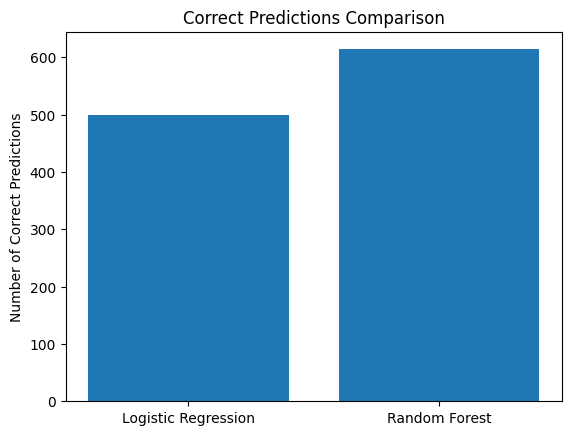

In [49]:
import matplotlib.pyplot as plt

# Count correct predictions
lr_correct = (comparison["Actual"] == comparison["Logistic_Prediction"]).sum()
rf_correct = (comparison["Actual"] == comparison["RF_Prediction"]).sum()

models = ['Logistic Regression', 'Random Forest']
correct = [lr_correct, rf_correct]

plt.bar(models, correct)
plt.title("Correct Predictions Comparison")
plt.ylabel("Number of Correct Predictions")
plt.show()

**Random Forest has more correct predictions compared to Logistic Regression, so it performs better for loan approval prediction.**

**Step 13: Saving Trained Model to Drive (Random Forest)**

In [50]:
import joblib

joblib.dump(rf, "/content/drive/MyDrive/Loan_Prediction_Project/loan_model.pkl")

['/content/drive/MyDrive/Loan_Prediction_Project/loan_model.pkl']

In [51]:
import json

with open("/content/drive/MyDrive/Loan_Prediction_Project/features.json", "w") as f:
    json.dump(list(X.columns), f)